In [1]:
import pandas as pd
import folium

df = pd.read_csv("feature_engineered_accidents.csv")

C:\Users\klarikach\AppData\Local\Temp\ipykernel_15780\2867345792.py:4: DtypeWarning: Columns (0: collision_index, 1: collision_ref_no) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("feature_engineered_accidents.csv")


In [2]:
df.columns.tolist()

['collision_index',
 'collision_year',
 'collision_ref_no',
 'location_easting_osgr',
 'location_northing_osgr',
 'longitude',
 'latitude',
 'police_force',
 'collision_severity',
 'number_of_vehicles',
 'number_of_casualties',
 'date',
 'day_of_week',
 'time',
 'local_authority_district',
 'local_authority_ons_district',
 'local_authority_highway',
 'local_authority_highway_current',
 'first_road_class',
 'first_road_number',
 'road_type',
 'speed_limit',
 'junction_detail_historic',
 'junction_detail',
 'junction_control',
 'second_road_class',
 'second_road_number',
 'pedestrian_crossing_human_control_historic',
 'pedestrian_crossing_physical_facilities_historic',
 'pedestrian_crossing',
 'light_conditions',
 'weather_conditions',
 'road_surface_conditions',
 'special_conditions_at_site',
 'carriageway_hazards_historic',
 'carriageway_hazards',
 'urban_or_rural_area',
 'did_police_officer_attend_scene_of_accident',
 'trunk_road_flag',
 'lsoa_of_accident_location',
 'enhanced_severit

In [3]:
df[['latitude','longitude']].isnull().sum()

latitude     0
longitude    0
dtype: int64

In [4]:
accident_map = folium.Map(
    location=[
        df['latitude'].mean(),
        df['longitude'].mean()
    ],
    zoom_start=6
)

In [5]:
sample = df.sample(1000)

In [6]:
for _, row in sample.iterrows():
    folium.CircleMarker(
        location=[
            row['latitude'],
            row['longitude']
        ],
        radius=3
    ).add_to(accident_map)

In [7]:
accident_map.save(
    "accident_locations.html"
)

In [10]:
df['local_authority_district'].value_counts().head(20)

local_authority_district
-1      513554
 241        32
 245        31
 243        27
 240        25
 476        14
 472        14
 471        10
 480         9
 474         7
 470         7
 473         6
 477         5
 475         4
 478         3
Name: count, dtype: int64

<Axes: xlabel='local_authority_district'>

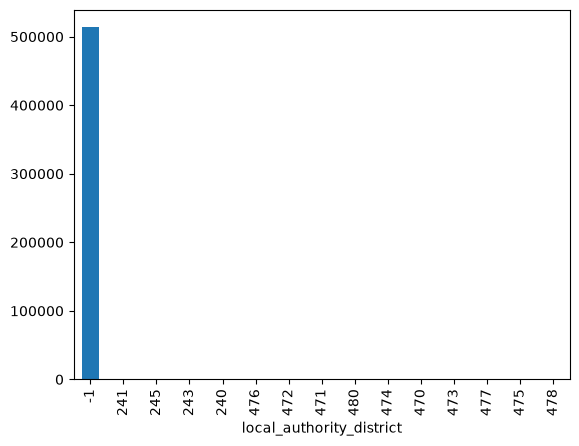

In [12]:
df['local_authority_district'].value_counts().head(20).plot(
    kind='bar'
)

In [13]:
hotspots = (
    df.groupby(
        ['latitude','longitude']
    )
    .size()
    .reset_index(name='accident_count')
)

In [14]:
hotspots.sort_values(
    'accident_count',
    ascending=False
).head(20)

,latitude,longitude,accident_count
306772,52.464664,-1.936002,6
445556,53.768396,-1.746229,6
458656,53.824432,-1.532164,6
438146,53.733547,-1.576571,5
448695,53.782614,-1.782293,5
94441,51.387210,-0.111100,4
192354,51.548733,-0.231144,4
467847,54.012910,-0.990260,4
134612,51.472829,-0.191690,4
126651,51.460250,-0.010860,4


## Geospatial Insights

- Major accident clusters are concentrated in urban areas.
- High-density collision points indicate potential traffic bottlenecks.
- Repeated accident coordinates suggest infrastructure or routing concerns.
- Several hotspots may benefit from traffic management interventions.